# SHAP

SHAP feature importance analysis

In [1]:
import numpy as np
import json

import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parents[0]))

def safe_parse(val):
    try:
        if pd.isna(val): return None
    except (TypeError, ValueError): pass
    while isinstance(val, str):
        try: val = ast.literal_eval(val)
        except (ValueError, SyntaxError): break
    return val

In [19]:
with open("random_stratified_splits_reg.json") as f:
    splits = json.load(f)

folds        = splits["folds"]
test_idx     = splits["test"]
all_idx      = np.arange(407)
trainval_idx = np.setdiff1d(all_idx, test_idx)
print(f"trainval={len(trainval_idx)}  test={len(test_idx)}  folds={len(folds)}")

trainval=345  test=62  folds=5


In [20]:
import joblib

In [21]:
import warnings, joblib, xgboost as xgb

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    clf_xgb  = joblib.load("../Classifier/saved_models_all/cls_xgb_pooled_poly.pkl")   # classifier
    reg_xgb  = joblib.load("saved_models_all/reg_xgb_pooled_ru.pkl")   # regressor
    X_scaler = joblib.load("saved_models_all/reg_xgb_pooled_ru_xscaler.pkl")

In [22]:
X_fp_pooled_RU    = np.load("Vectors/X_fp_pooled_RU.npy")

In [23]:
# Scale test features the same way as during training
X_test_scaled = X_scaler.transform(X_fp_pooled_RU[test_idx])

In [24]:
model = reg_xgb
X     = X_test_scaled

Computing SHAP values...

Top 5 features:
    feature       category  mean_abs_shap
   RotBonds   Node Feature      19.792227
flexibility   Node Feature      14.437167
       LogP   Node Feature       7.333584
         Pm Global Feature       7.285686
Heteroatoms   Node Feature       6.265864


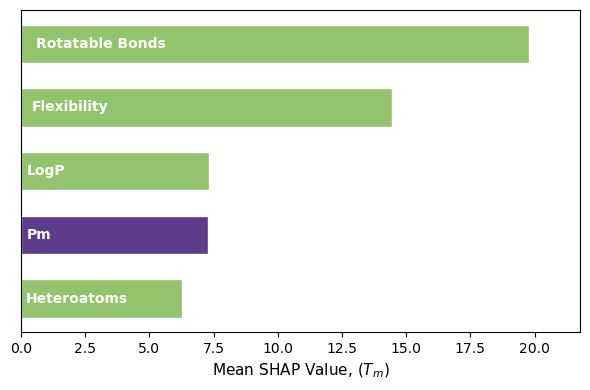

Saved: ./shap_top5_bar_reg.png


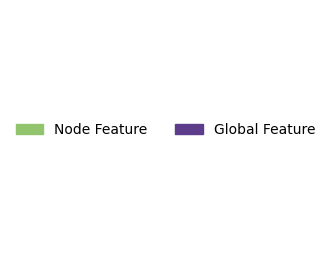

Saved: ./shap_category_legend.png
Saved: ./shap_top5_summary_reg.csv


In [29]:
%run -i scripts/shap_analysis.py

In [26]:
with open("../Classifier/random_stratified_splits_cls.json") as f:
    splits = json.load(f)

folds        = splits["folds"]
test_idx     = splits["test"]
all_idx      = np.arange(643)
trainval_idx = np.setdiff1d(all_idx, test_idx)
print(f"trainval={len(trainval_idx)}  test={len(test_idx)}  folds={len(folds)}")

trainval=546  test=97  folds=5


In [11]:
import warnings, joblib, xgboost as xgb

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    clf_xgb  = joblib.load("../Classifier/saved_models_all/cls_xgb_pooled_poly.pkl")   # classifier

In [12]:
X_fp_pooled_poly    = np.load("../Classifier/Vectors/X_fp_pooled_poly.npy")

In [13]:
model = clf_xgb
X     = X_fp_pooled_poly[test_idx]

Computing SHAP values...

Top 5 features:
          feature       category  mean_abs_shap
               Pm Global Feature       1.327900
   backbone_atoms   Node Feature       0.741168
        kier_flex   Node Feature       0.473790
             LogP   Node Feature       0.433126
avg_branch_length   Node Feature       0.339365


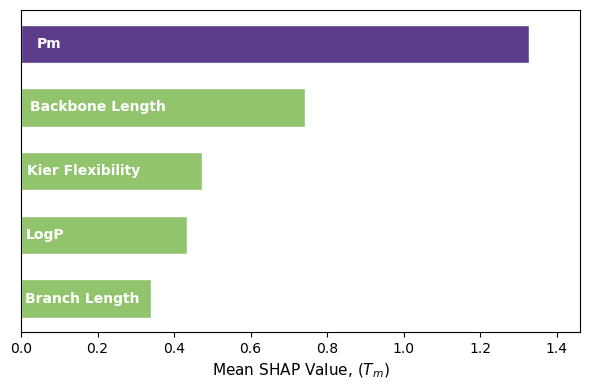

Saved: ./shap_top5_bar.png


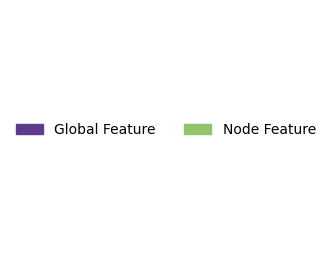

Saved: ./shap_category_legend.png
Saved: ./shap_top5_summary.csv


In [14]:
%run -i scripts/shap_analysis.py